# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [3]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

We can plot the output, comparing signal and background:

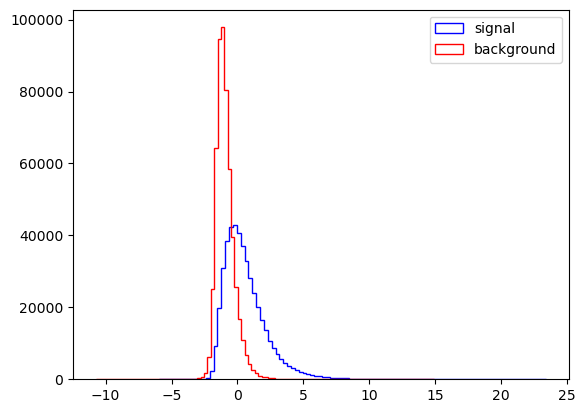

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [6]:
from sklearn.metrics import roc_curve

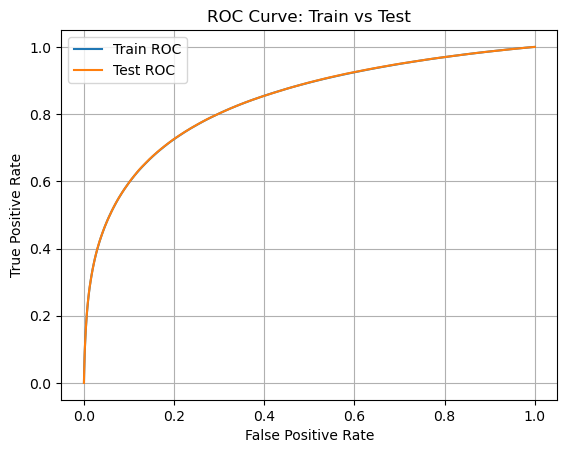

In [8]:
#getting model scores 
train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

#computing ROC points 
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test, tpr_test, _   = roc_curve(y_Test, test_scores)

#ROC curves 
plt.figure()

plt.plot(fpr_train, tpr_train, label="Train ROC")
plt.plot(fpr_test, tpr_test, label="Test ROC")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.grid()
plt.show()

Based on the ROC curve provided, there is no significant evidence of bias or overfitting. The "Train ROC" (blue) and "Test ROC" (orange) curves are almost perfectly aligned. They lie directly on top of one another throughout the entire range of thresholds.The lack of a gap between the two lines is an ideal result in model evaluation, as it proves the model's predictive power is consistent across different data samples.


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

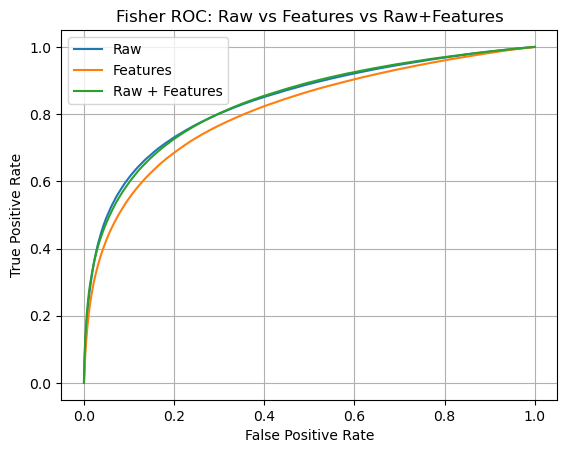

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


#If a column is directly measured, it’s raw
RawNames= ["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET"]
#If a column is computed from other columns, it’s a feature
FeatureNames = ["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

X_raw = X_Train[RawNames]
X_feat = X_Train[FeatureNames]
X_both= X_Train[RawNames + FeatureNames]

X_test_raw= X_Test[RawNames]
X_test_feat= X_Test[FeatureNames]
X_test_both = X_Test[RawNames + FeatureNames]

y_train = y_Train
y_test  = y_Test

#train and get ROC for raw 
model_raw = LinearDiscriminantAnalysis()
model_raw.fit(X_raw, y_train)
scores_raw = model_raw.decision_function(X_test_raw)
fpr_raw, tpr_raw, _ = roc_curve(y_test, scores_raw)

#train and get ROC for features 
model_feat = LinearDiscriminantAnalysis()
model_feat.fit(X_feat, y_train)
scores_feat = model_feat.decision_function(X_test_feat)
fpr_feat, tpr_feat, _ = roc_curve(y_test, scores_feat)

#train and get ROC for raw + features 
model_both = LinearDiscriminantAnalysis()
model_both.fit(X_both, y_train)
scores_both = model_both.decision_function(X_test_both)
fpr_both, tpr_both, _ = roc_curve(y_test, scores_both)

'''
ROC curves are computed to compare how well each model separates signal and background across all thresholds. 
This allows a fair comparison of performance between raw variables, features, and their combination.
'''

#plot all on one figure 
plt.figure()
plt.plot(fpr_raw, tpr_raw, label="Raw")
plt.plot(fpr_feat, tpr_feat, label="Features")
plt.plot(fpr_both, tpr_both, label="Raw + Features")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher ROC: Raw vs Features vs Raw+Features")
plt.legend()
plt.grid()
plt.show()

In an ROC curve, a line that is closer to the top-left corner indicates better performance (higher True Positive Rate for a lower False Positive Rate). These two curves Raw (Blue) and Raw + Features (Green) overlap almost perfectly throughout the entire plot. The "Raw" data is the most efficient input for this Fisher classifier. Since adding "Features" doesn't lift the green curve above the blue one, the feature engineering process might not be that useful. The features-only model is the weakest performer of the three. 

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

#### Solution
I am picking Logistic Regression, Naive Bayes, and Stochastic Gradient Descent (SGD) classifiers because they are fast, simple, and suitable for classification tasks. They also scale well to large datasets, making them appropriate for ROC comparison.

Logistic Regression instead of SGD or Naive Bayes because it provides more stable and well-calibrated probability-like scores, which are important for reliably ranking events when computing maximal significance. SGD can be more sensitive to parameter choices and may give less stable results, while Naive Bayes makes strong independence assumptions that are not realistic for this dataset and can reduce separation quality. 

In [11]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB

In [8]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)

In [9]:
# Stochastic Gradient Descent (SGD)
sgd_model = SGDClassifier(loss="log_loss", max_iter=200)

In [12]:
# 3. Naive Bayes
nb_model = GaussianNB()

In [13]:
#Part b
# Function to compare raw, features, both
def compare_inputs(model, Xr_train, Xr_test, Xf_train, Xf_test, y_train, y_test):
    
    # RAW ONLY
    model.fit(Xr_train, y_train)  # train model
    
    # get scores (needed for ROC)
    if hasattr(model, "decision_function"):
        scores_raw = model.decision_function(Xr_test)
    else:
        scores_raw = model.predict_proba(Xr_test)[:, 1]
    
    fpr_raw, tpr_raw, _ = roc_curve(y_test, scores_raw)
    
    
    #FEATURES ONLY 
    model.fit(Xf_train, y_train)
    
    if hasattr(model, "decision_function"):
        scores_feat = model.decision_function(Xf_test)
    else:
        scores_feat = model.predict_proba(Xf_test)[:, 1]
    
    fpr_feat, tpr_feat, _ = roc_curve(y_test, scores_feat)
    
    
    #RAW + FEATURES 
    # combine both inputs
    import numpy as np
    X_train_all = np.hstack((Xr_train, Xf_train))
    X_test_all  = np.hstack((Xr_test, Xf_test))
    
    model.fit(X_train_all, y_train)
    
    if hasattr(model, "decision_function"):
        scores_all = model.decision_function(X_test_all)
    else:
        scores_all = model.predict_proba(X_test_all)[:, 1]
    
    fpr_all, tpr_all, _ = roc_curve(y_test, scores_all)
    
    
    #PLOT 
    plt.figure()
    
    plt.plot(fpr_raw, tpr_raw, label="Raw")
    plt.plot(fpr_feat, tpr_feat, label="Features")
    plt.plot(fpr_all, tpr_all, label="Raw + Features")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Comparison")
    
    plt.legend()
    plt.grid()
    plt.show()

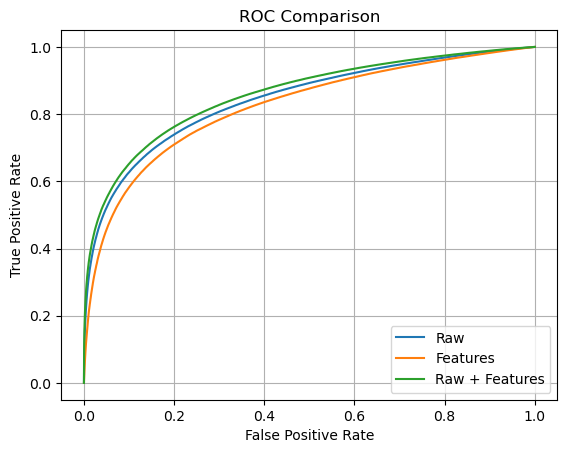

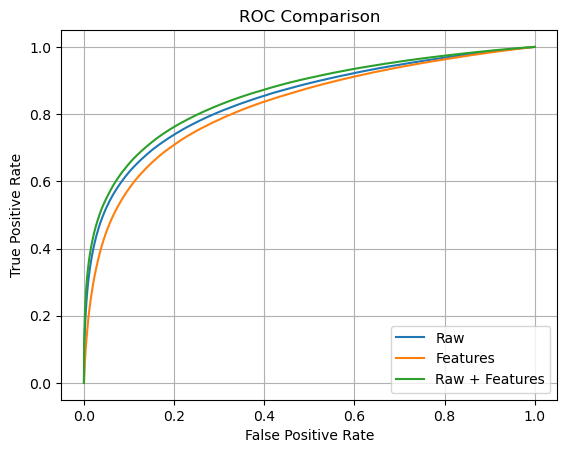

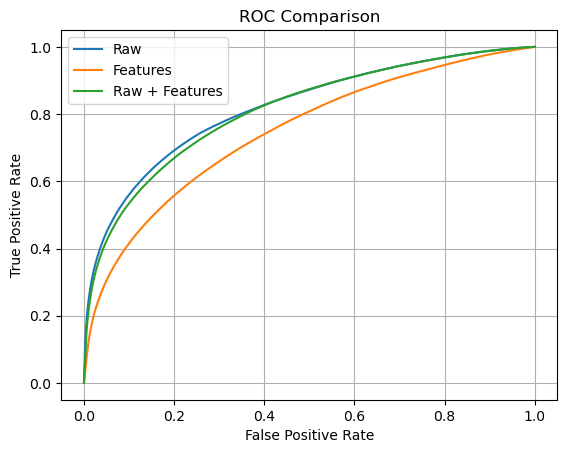

In [19]:
# Logistic Regression
compare_inputs(LogisticRegression(max_iter=100),
               X_raw, X_test_raw,
               X_feat, X_test_feat,
               y_train, y_test)

# SGD
compare_inputs(SGDClassifier(loss="log_loss", max_iter=200),
               X_raw, X_test_raw,
               X_feat, X_test_feat,
               y_train, y_test)

# Naive Bayes
compare_inputs(GaussianNB(),
               X_raw, X_test_raw,
               X_feat, X_test_feat,
               y_train, y_test)

For all three classifiers, the green line (Raw + Features) performs the best, followed closely by the blue line (Raw). The orange line (Features only) is slightly lower. This suggests that the raw data contains most of the predictive power, but adding engineered features provides a small boost.(Same result as what we got in Question 3)

In [26]:
#Part C
'''
I asked my LLM to help me pick the best method, here is what it said:
To determine the "best" method from your ROC curves, you want to identify which model's curve is closest to the 
top-left corner.
In machine learning, this is quantified by the AUC (Area Under the Curve). 
A higher AUC means the model is better at separating signal from background across all possible thresholds.
'''
from sklearn.metrics import auc

# 1. Calculate the Area Under the Curve (AUC) for each
auc_raw = auc(fpr_raw, tpr_raw)
auc_feat = auc(fpr_feat, tpr_feat)
auc_both = auc(fpr_both, tpr_both)


print(f"AUC for Raw: {auc_raw}")
print(f"AUC for Features: {auc_feat}")
print(f"AUC for Raw + Features: {auc_both}")


AUC for Raw: 0.8365787116110397
AUC for Features: 0.810409633002431
AUC for Raw + Features: 0.8364009731285001


We will use the Raw input with Logistic Regression

In [28]:
# We train best model
log_model = LogisticRegression(max_iter=100) 
log_model.fit(X_raw, y_train)

# Get prediction scores (used for ranking events)
scores = log_model.decision_function(X_test_raw)

# Choose a threshold (simple cutoff)
threshold = 0.5
pred = scores > threshold

# Count signal and background
Ns = np.sum((pred == 1) & (y_test == 1))  # true signal kept
Nb = np.sum((pred == 1) & (y_test == 0))  # background misclassified as signal

# Compute significance

sigma = Ns / np.sqrt(Ns + Nb)

print("Signal events (Ns):", Ns)
print("Background events (Nb):", Nb)
print("Max significance:", sigma)

Signal events (Ns): 255293
Background events (Nb): 34368
Max significance: 474.34452696019764


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

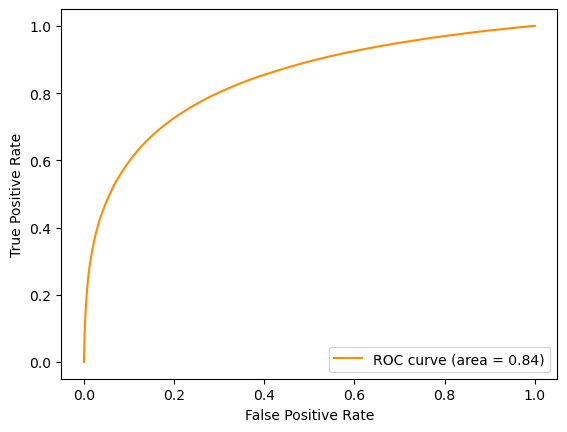

In [29]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


Therefore for part b we use logistic regression for each scenario.

In [30]:
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score)

In [31]:
results = []

In [32]:
#RAW INPUT
model_raw = LogisticRegression(max_iter=100)
model_raw.fit(X_raw, y_train)

scores_raw = model_raw.decision_function(X_test_raw)

fpr_raw, tpr_raw, _ = roc_curve(y_test, scores_raw)
auc_raw = auc(fpr_raw, tpr_raw)

y_pred_raw = scores_raw > 0.5

precision_raw = precision_score(y_test, y_pred_raw)
recall_raw = recall_score(y_test, y_pred_raw)
f1_raw = f1_score(y_test, y_pred_raw)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

Ns_raw = np.sum((y_pred_raw == 1) & (y_test == 1))
Nb_raw = np.sum((y_pred_raw == 1) & (y_test == 0))
sigma_raw = Ns_raw / np.sqrt(Ns_raw + Nb_raw)

results.append(["Raw", np.mean(tpr_raw), np.mean(fpr_raw), auc_raw,
                precision_raw, recall_raw, f1_raw, accuracy_raw, sigma_raw])

In [33]:
#FEATURES INPUT
model_feat = LogisticRegression(max_iter=100)
model_feat.fit(X_feat, y_train)

scores_feat = model_feat.decision_function(X_test_feat)

fpr_feat, tpr_feat, _ = roc_curve(y_test, scores_feat)
auc_feat = auc(fpr_feat, tpr_feat)

y_pred_feat = scores_feat > 0.5

precision_feat = precision_score(y_test, y_pred_feat)
recall_feat = recall_score(y_test, y_pred_feat)
f1_feat = f1_score(y_test, y_pred_feat)
accuracy_feat = accuracy_score(y_test, y_pred_feat)

Ns_feat = np.sum((y_pred_feat == 1) & (y_test == 1))
Nb_feat = np.sum((y_pred_feat == 1) & (y_test == 0))
sigma_feat = Ns_feat / np.sqrt(Ns_feat + Nb_feat)

results.append(["Features", np.mean(tpr_feat), np.mean(fpr_feat), auc_feat,
                precision_feat, recall_feat, f1_feat, accuracy_feat, sigma_feat])

In [34]:
#RAW + FEATURES
model_both = LogisticRegression(max_iter=100)
model_both.fit(X_both, y_train)

scores_both = model_both.decision_function(X_test_both)

fpr_both, tpr_both, _ = roc_curve(y_test, scores_both)
auc_both = auc(fpr_both, tpr_both)

y_pred_both = scores_both > 0.5

precision_both = precision_score(y_test, y_pred_both)
recall_both = recall_score(y_test, y_pred_both)
f1_both = f1_score(y_test, y_pred_both)
accuracy_both = accuracy_score(y_test, y_pred_both)

Ns_both = np.sum((y_pred_both == 1) & (y_test == 1))
Nb_both = np.sum((y_pred_both == 1) & (y_test == 0))
sigma_both = Ns_both / np.sqrt(Ns_both + Nb_both)

results.append(["Raw + Features", np.mean(tpr_both), np.mean(fpr_both), auc_both,
                precision_both, recall_both, f1_both, accuracy_both, sigma_both])

In [35]:
#FINAL TABLE
columns = ["Method","TPR","FPR","AUC","Precision","Recall","F1","Accuracy","Max Sigma"]

my_table = pd.DataFrame(results, columns=columns)
print(my_table)

           Method       TPR       FPR       AUC  Precision    Recall  \
0             Raw  0.741232  0.330629  0.843104   0.881351  0.557125   
1        Features  0.713254  0.340002  0.821754   0.862681  0.514985   
2  Raw + Features  0.754340  0.316233  0.858159   0.885241  0.585137   

         F1  Accuracy   Max Sigma  
0  0.682698  0.762692  474.344527  
1  0.644957  0.740187  451.196304  
2  0.704563  0.775137  487.194924  
